## Analysing Destination Earth Climate Digital Twins with earthkit

This notebook works through a full analysis pipeline on multi-decadal Climate DT output: retrieval, regridding, temporal averaging, comparison against ERA5 reanalysis, climatology, anomaly calculation, spatial aggregation to administrative regions, and warming-stripe visualisation.

**What you will learn**
- How to retrieve a multi-year monthly dataset from the Climate DT baseline stream
- How to retrieve matching ERA5 data from the CDS for comparison
- How to regrid and compute temporal means with `earthkit.transforms`
- How to compute climatologies and anomalies
- How to spatially aggregate to NUTS administrative regions
- How to make choropleth and warming-stripe charts with `earthkit.plots`

This notebook uses the following components of earthkit:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-transforms.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-transforms-light.svg" alt="earthkit-transforms" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-geo-light.svg" alt="earthkit-geo" width="200">
  </a>
</div>

## Setup

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.geo as ekg
import earthkit.transforms as ekt
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

### Retrieve the Climate DT baseline run (IFS-NEMO)

The **baseline** activity contains historical simulations driven by observed forcing.  Here we pull
the IFS-NEMO coupled model, monthly-mean 2 m temperature (`param: 228004`), for all 25 years of
the 1990–2014 period across all 12 months.

**Key differences from the projections request in notebook 01**

| Field | Value | Meaning |
|-------|-------|---------|
| `activity` | `baseline` | Historical run |
| `experiment` | `hist` | Historical forcing |
| `stream` | `clmn` | Climate **monthly** mean stream |
| `year` | `1990/to/2014` | 25-year range using Polytope range syntax |
| `month` | `1/2/.../12` | All calendar months |

This produces 300 fields (25 years × 12 months), each on the native HEALPix grid.  The download
is ~126 MB.

In [2]:
request = {
    "class": "d1",
    "dataset": "climate-dt",
    "type": "fc",
    "expver": "0001",
    "generation": "2",
    "realization": "1",
    "activity": "baseline",
    "experiment": "hist",
    "model": "ifs-fesom",
    "param": "228004",  # 2 m temperature, monthly mean
    "levtype": "sfc",
    "resolution": "standard",
    "stream": "clmn",
    "year": "1990/to/2014",
    "month": "1/2/3/4/5/6/7/8/9/10/11/12",
}

ifs_nemo = ekd.from_source(
    "polytope",
    "destination-earth",
    request,
    address="polytope.lumi.apps.dte.destination-earth.eu",
    stream=False,
)

2026-06-05 11:57:40 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-05 11:57:40 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            'month: 1/2/3/4/5/6/7/8/9/10/11/12\n'
            "param: '228004'\n"
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            'year: 1990/to/2014\n',
 'verb': 'retrieve'}
2026-06-05 11:57:40 - INFO - Polytope user key found in session cache for user mavj
2026-06-05 11:57:40 - INFO - Request accepted. Please poll ./148b7aa6-095f-4fc9-9c3d-db373ac145ea for status
2026-06-05 11:57:40 - INFO - Polytope user key found in session cache for user mavj
2026-06-05 11:57:40 - INFO - Checking request status (148b7aa6-095f-4fc9-9c3d-db373ac14

148b7aa6-095f-4fc9-9c3d-db373ac145ea.grib:   0%|          | 0.00/126M [00:00<?, ?B/s]

### Retrieve ERA5 reanalysis from the Cliamte Data Store for the same period

ERA5 is ECMWF's fifth-generation global reanalysis, widely used as the reference observational
climatology.  We pull the same variable (2 m temperature), same period, and same temporal
resolution (monthly means) from the Copernicus Climate Data Store (CDS).

The CDS request uses a different vocabulary (`product_type`, `variable` by name) but earthkit
normalises both datasets into the same interface, so downstream code is identical.

Note that in order to access data from the Climate Data Store, you need to register and [set up your API key access](https://cds.climate.copernicus.eu/how-to-api).

In [3]:
dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["2m_temperature"],
    "year": [str(year) for year in range(1990, 2015)],
    "month": [f"{month:02d}" for month in range(1, 13)],
    "time": ["00:00"],
    "data_format": "grib",
    "download_format": "unarchived",
}
era5 = ekd.from_source("cds", dataset, request)

2026-06-05 11:57:50,637 INFO Request ID is b52841e4-9e59-49f5-a911-8d7c346ed929
2026-06-05 11:57:50,755 INFO status has been updated to accepted
2026-06-05 11:58:00,060 INFO status has been updated to running
2026-06-05 11:58:04,065 INFO status has been updated to successful


88ad061b656d8f83cd400ba487034079.grib:   0%|          | 0.00/594M [00:00<?, ?B/s]


Before committing to heavy computation, it's worth visually checking that both datasets look
reasonable for the same date.  `ekp.Figure` with `rows=1, columns=2` places both maps in a single
row.  We use December 2014 (the last month in the dataset) as a representative snapshot.

At this point the IFS-NEMO data is still on the HEALPix grid and ERA5 is on its native 0.25 °
regular lat-lon grid — the `grid_cells` renderer handles both transparently.

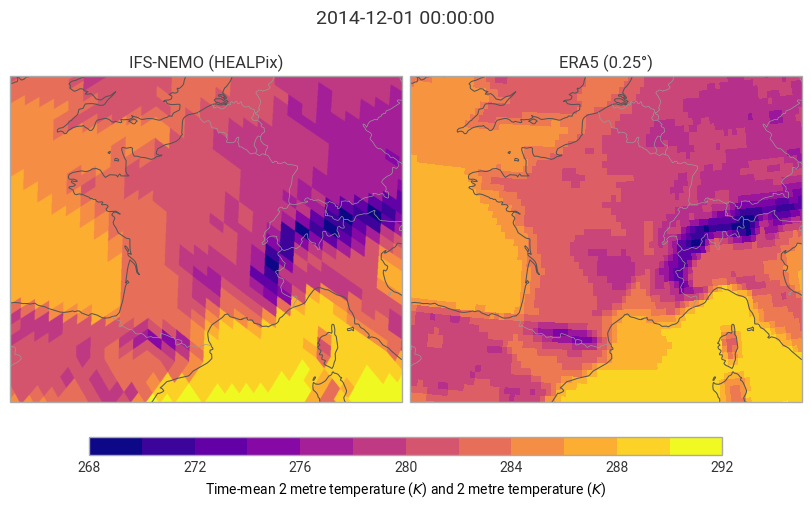

In [4]:
DATE = "2014-12-01"

fig = ekp.Figure(rows=1, columns=2, domain=["France", "Belgium"])

fig.add_map().grid_cells(ifs_nemo.to_fieldlist().sel({"time.valid_datetime": DATE}))
fig.add_map().grid_cells(era5.to_fieldlist().sel({"time.valid_datetime": DATE}))

fig.title("{time.valid_datetime}", y=0.7)
fig[0].title("IFS-NEMO (HEALPix)")
fig[1].title("ERA5 (0.25°)")
fig.legend()

fig.coastlines()
fig.borders()

### Regridding with earthkit-geo

To do arithmetic between IFS-NEMO and ERA5 we need them on the same grid.  We regrid IFS-NEMO
down to the ERA5 native resolution (0.25 ° × 0.25 °) using bilinear interpolation.

This is computationally the most expensive step (~300 fields).  The interpolation weights are
cached so re-runs are fast.

In [5]:
ifs_nemo_regridded = ekg.regrid(ifs_nemo.to_fieldlist(), [0.25, 0.25])

### Verify the regridded snapshot

A quick visual check that the regridded IFS-NEMO field looks plausible before we proceed.

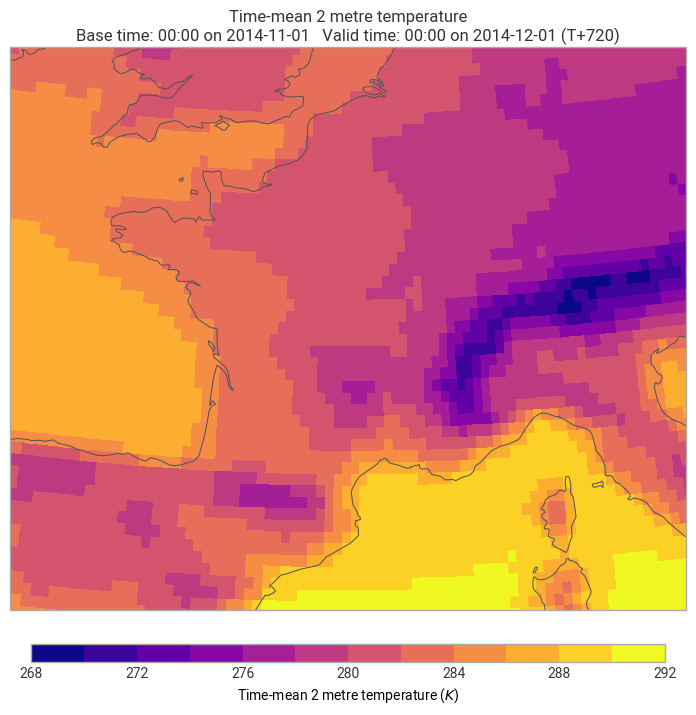

In [6]:
ekp.geo.grid_cells(
    ifs_nemo_regridded.sel({"time.valid_datetime": DATE}),
    domain=["France", "Belgium"]
)

### Statistics with earthkit-transforms

`ekt.temporal.mean` collapses the time dimension, returning a single field per variable that
represents the 1990–2014 mean.  This is done on xarray Datasets (after `.to_xarray()`) for
IFS-NEMO, and directly on the fieldlist for ERA5 — both paths produce compatible results.

We rename the IFS-NEMO variable from `avg_2t` to `2t` to match the ERA5 naming before
computing the difference.

In [7]:
ifs_nemo_mean = (
    ekt.temporal.mean(ifs_nemo_regridded.to_xarray(time_dims="valid_time"))
    .rename_vars({"avg_2t": "2t"})
)

In [8]:
era5_mean = ekt.temporal.mean(era5)

The difference ERA5 − IFS-NEMO gives the model bias: positive values mean IFS-NEMO is too cold,
negative values mean it is too warm.  Because both objects are on the same grid and xarray tracks
coordinates, the subtraction aligns by coordinate automatically.

In [9]:
diff = ifs_nemo_mean - era5_mean

We plot the 25-year mean for each dataset and their difference in a 2 × 2 Figure (with the
difference spanning the full bottom row).  The Robinson projection works well for global maps.

The diverging `RdBu_r` palette on the difference panel makes warm and cold biases immediately
legible: blue = IFS-NEMO is warmer than ERA5, red = IFS-NEMO is colder.

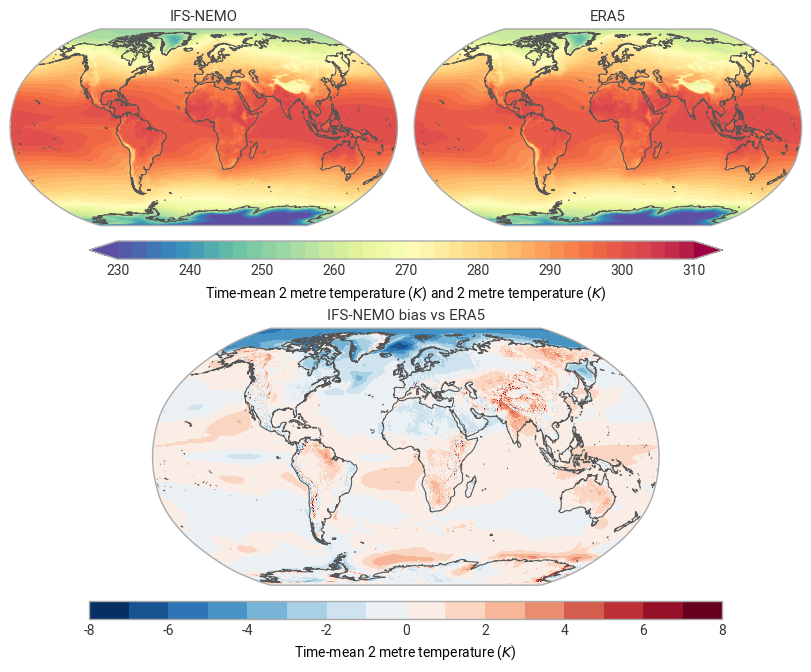

In [10]:
fig = ekp.Figure(crs="Robinson", rows=2, columns=2)

climatedt_plot = fig.add_map()
climatedt_plot.plot(ifs_nemo_mean)
climatedt_plot.title("IFS-NEMO")

era5_plot = fig.add_map()
era5_plot.plot(era5_mean)
era5_plot.title("ERA5")

diff_plot = fig.add_map(row=1, column=slice(0, 2))
diff_plot.grid_cells(diff, levels=range(-8, 9), colors="RdBu_r")
diff_plot.title("IFS-NEMO bias vs ERA5")

fig.title("{time}")
fig.coastlines()
fig.legend()

fig.show()

### Spatial and temporal statistics

The remaining sections use the full regridded IFS-NEMO time series to compute climatologies,
anomalies, and spatially-aggregated statistics.

`ekt.climatology.mean` computes the long-term mean (here averaged over all months and years).
`ekt.climatology.anomaly` subtracts it from each time step at the requested frequency — `"year"`
means we first average each calendar year before computing the departure from the climatology,
giving one anomaly field per year.

In [11]:
ds = ifs_nemo_regridded.to_xarray(time_dims="valid_time")

climatology_mean = ekt.climatology.mean(ds)
anom = ekt.climatology.anomaly(ds, climatology_mean, frequency="year")

In [12]:
# Inspect the anomaly dataset: 25 annual time steps on the 0.25° grid
anom

<xarray.Dataset> Size: 216MB
Dimensions:     (latitude: 721, longitude: 1440, valid_time: 26)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * valid_time  (valid_time) datetime64[ns] 208B 1990-12-31 ... 2015-12-31
Data variables:
    avg_2t      (valid_time, latitude, longitude) float64 216MB 0.9208 ... 18.28
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

NUTS (Nomenclature of Territorial Units for Statistics) is the EU's hierarchical system for
administrative regions.  Level 0 corresponds to countries.  earthkit ships this dataset as a
built-in sample so no separate download is needed.

In [13]:
nuts_level_0 = ekd.from_source("sample", "NUTS_RG_60M_2021_4326_LEVL_0.geojson").to_pandas()

NUTS_RG_60M_2021_4326_LEVL_0.geojson:   0%|          | 0.00/68.4k [00:00<?, ?B/s]

`ekt.spatial.reduce` aggregates gridded data to arbitrary polygons.  Key options:

| Option | Value | Effect |
|--------|-------|--------|
| `weights="latitude"` | cosine-area weighting | Corrects for grid cells shrinking toward the poles |
| `mask_dim="NAME_LATN"` | region label column | Names each aggregated region |
| `return_as="pandas"` | output format | Returns a tidy DataFrame |
| `all_touched=True` | rasterisation rule | Includes cells that touch a polygon boundary |

We select a single anomaly year before aggregating to keep the computation fast.

In [14]:
YEAR = 2008

nuts_anom = ekt.spatial.reduce(
    anom.sel(valid_time=f"{YEAR}-12-31"),
    nuts_level_0,
    weights="latitude",
    mask_dim="NAME_LATN",
    return_as="pandas",
    all_touched=True,
)
nuts_anom

,id,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,valid_time,avg_2t
NAME_LATN,,,,,,,,,,,,,
Danmark,DK,DK,0,DK,Danmark,Danmark,0,0,0,DK,"MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...",2008-12-31,0.573214
Serbia,RS,RS,0,RS,Serbia,Srbija/Сpбија,0,0,0,RS,"POLYGON ((21.4792 45.193, 21.3585 44.8216, 22....",2008-12-31,0.638894
Eesti,EE,EE,0,EE,Eesti,Eesti,0,0,0,EE,"MULTIPOLYGON (((27.357 58.7871, 27.6449 57.981...",2008-12-31,-0.140054
Elláda,EL,EL,0,EL,Elláda,Ελλάδα,0,0,0,EL,"MULTIPOLYGON (((28.0777 36.1182, 27.8606 35.92...",2008-12-31,0.385529
España,ES,ES,0,ES,España,España,0,0,0,ES,"MULTIPOLYGON (((4.391 39.8617, 4.1907 39.7981,...",2008-12-31,0.238526
Suomi/Finland,FI,FI,0,FI,Suomi/Finland,Suomi/Finland,0,0,0,FI,"MULTIPOLYGON (((28.8967 69.0426, 28.4782 68.51...",2008-12-31,0.025170
France,FR,FR,0,FR,France,France,0,0,0,FR,"MULTIPOLYGON (((55.8498 -21.1858, 55.7858 -21....",2008-12-31,0.344974
Hrvatska,HR,HR,0,HR,Hrvatska,Hrvatska,0,0,0,HR,"MULTIPOLYGON (((17.6515 45.8478, 17.9121 45.79...",2008-12-31,0.275761
Magyarország,HU,HU,0,HU,Magyarország,Magyarország,0,0,0,HU,"POLYGON ((22.1211 48.3783, 22.1553 48.4034, 22...",2008-12-31,0.168932


A choropleth fills each polygon with a colour proportional to its aggregated value.  We add
direct data labels (`labels="{avg_2t:+.1f}°C"`) so the magnitude of the anomaly is readable
without needing to consult the legend.  The `+` format flag forces the sign to be shown on both
positive and negative values.

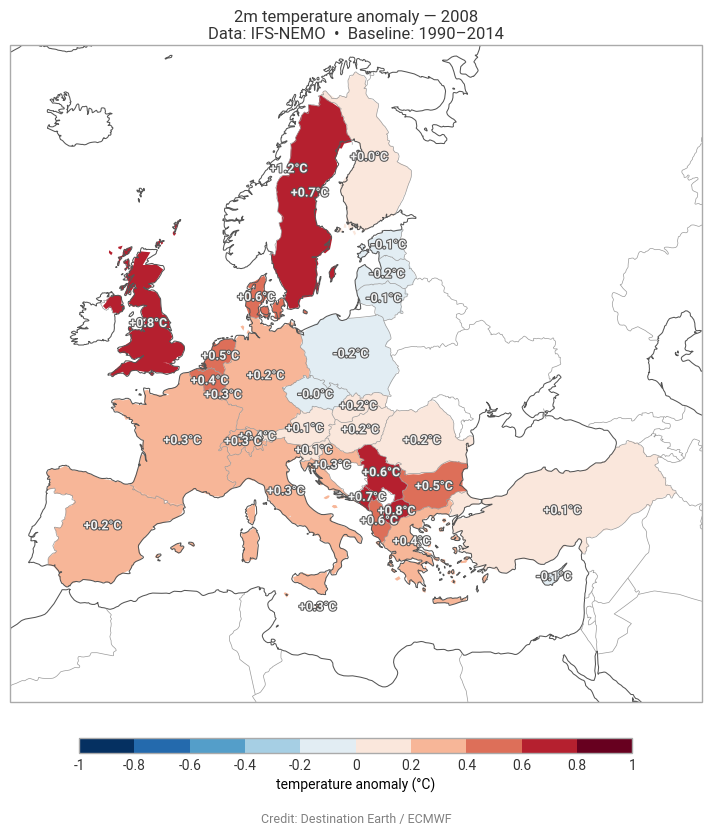

In [15]:
chart = ekp.Map(domain="Europe")

chart.choropleth(
    nuts_anom,
    z="avg_2t",
    levels=np.linspace(-1, 1, 11),
    colors="RdBu_r",
    zorder=0,
    labels="{avg_2t:+.1f}°C"
)

chart.legend(label="temperature anomaly (°C)")

chart.title(
    f"2m temperature anomaly — {YEAR}\n"
    "Data: IFS-NEMO  •  Baseline: 1990–2014"
)

chart.attribution("Credit: Destination Earth / ECMWF")

chart.coastlines()
chart.borders()
chart.show()

`ekt.spatial.reduce` without a polygon argument collapses to a single global mean value per time
step — effectively a globally-averaged time series.  We trim to the 1990–2013 range to exclude
the partial year at each end.

In [16]:
global_mean = ekt.spatial.reduce(anom).sel(valid_time=slice("1990-01-01", "2014-01-01"))

Warming stripes encode a temperature time series as a sequence of coloured bars — no axes, no
numbers, just colour.  Originally created by Ed Hawkins (University of Reading), the format has
become a widely recognised communication tool for climate change.

`ekp.timeseries.stripes` implements this directly.  We add sparse x-axis tick marks (every 5
years) and a brief title to provide just enough context.

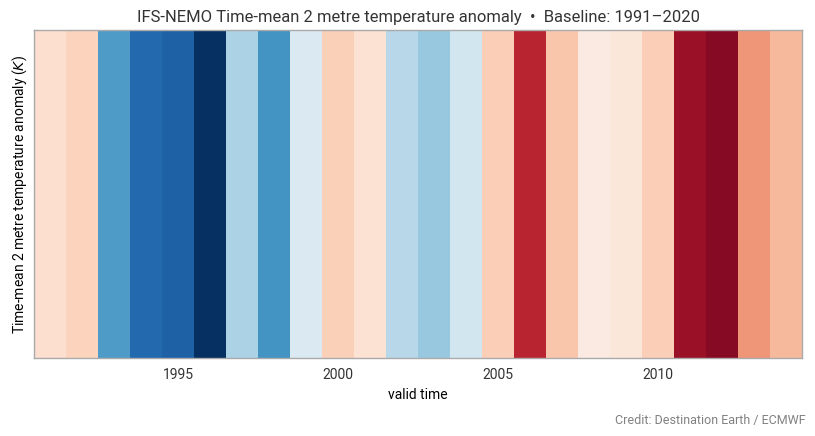

In [17]:
chart = ekp.timeseries.stripes(global_mean, cmap="RdBu_r")

chart.xticks(frequency="5Y")

chart.title("IFS-NEMO {variable_name}  •  Baseline: 1991–2020")
chart.attribution("Credit: Destination Earth / ECMWF", location="lower right")

chart.show()

### Exercises

1. Instead of finding the difference between IFS-NEMO and ERA5 over the whole time period, calculate monthly climatologies for both IFS-NEMO and ERA5 and find the differences for each month (hint: try `ekt.climatology.monthly_mean`). Do the biases change throughout the year?

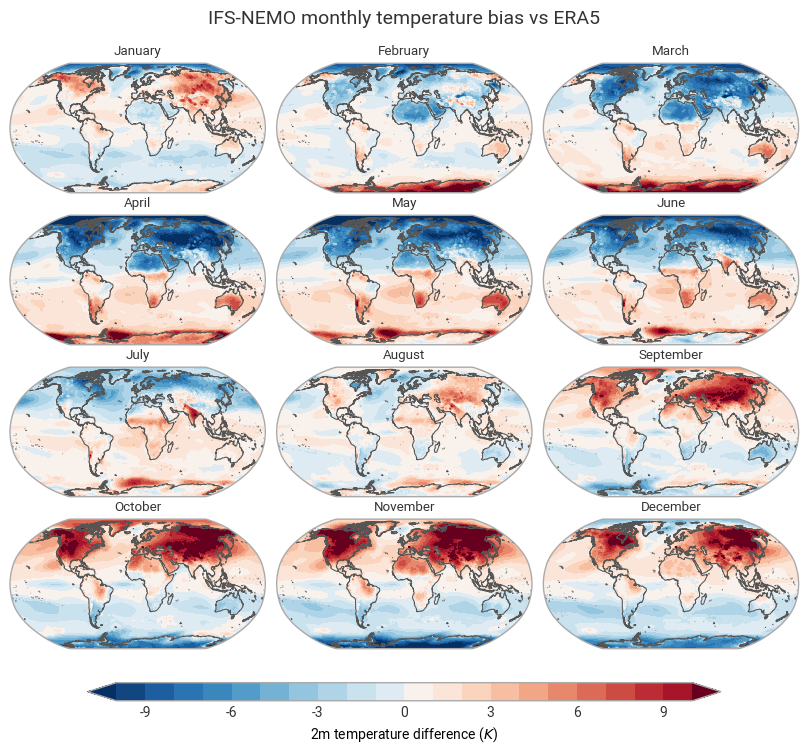

In [18]:
ifs_nemo_monthly_mean = ekt.climatology.monthly_mean(
    ifs_nemo_regridded.to_xarray(time_dims="valid_time")
).rename_vars({"avg_2t": "2t"})

era5_monthly_mean = ekt.climatology.monthly_mean(era5)

monthly_diff = ifs_nemo_monthly_mean - era5_monthly_mean

fig = ekp.Figure(crs="Robinson", rows=4, columns=3)

for month in range(1, 13):
    fig.add_map().plot(monthly_diff.sel(month=month), levels=range(-10, 11), colors="RdBu_r")
    
fig.subplot_titles("{month}")
fig.title("IFS-NEMO monthly temperature bias vs ERA5", y=1.05)
fig.legend(label="2m temperature difference ({units})")
fig.coastlines()

---
## Summary

In this notebook you built a complete analysis pipeline:

1. **Retrieved** 25 years of monthly IFS-NEMO and ERA5 data
2. **Regridded** IFS-NEMO from HEALPix to 0.25 ° to match ERA5
3. **Computed** 25-year temporal means and visualised the model bias globally
4. **Computed** annual temperature anomalies relative to the 1990–2014 climatology
5. **Aggregated** anomalies to NUTS-0 country polygons with area weighting
6. **Visualised** the results as a choropleth map and as warming stripes

To continue exploring earthkit, see the [earthkit website](https://earthkit.ecmwf.int/), [documentation](https://earthkit.readthedocs.io/en/latest/) or [GitHub](https://github.com/ecmwf/earthkit).